In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


2026-04-18 09:32:15.462904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776504735.677259      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776504735.739283      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776504736.235730      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776504736.235764      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776504736.235767      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
import shutil
import random
import librosa
import numpy as np
import soundfile as sf
from pathlib import Path

# ══════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════
# Read-only Kaggle input path
INPUT_DIR = "/kaggle/input/datasets/dwij45/speech-emotion-detection/Speech-Emotion-Detection"

# Writable Kaggle working path (update your main script's DATA_ROOT to this later!)
OUTPUT_DIR = "/kaggle/working/Augmented-Data"

# Ensure exact capitalization matches your folders
EMOTIONS = ["angry", "calm","disgust","fearful", "happy", "neutral", "sad", "surprised"]

TARGET_SR = 16000

# ══════════════════════════════════════════════════════════
# AUGMENTATION FUNCTIONS
# ══════════════════════════════════════════════════════════
def add_white_noise(y, noise_factor=0.005):
    """Injects low-level background static to improve model robustness."""
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

def shift_pitch(y, sr, n_steps):
    """Shifts pitch up or down slightly (simulates different vocal tract sizes)."""
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

def stretch_time(y, rate):
    """Speeds up or slows down speech without changing the pitch."""
    return librosa.effects.time_stretch(y=y, rate=rate)

# ══════════════════════════════════════════════════════════
# MAIN EXECUTION
# ══════════════════════════════════════════════════════════
def augment_dataset_2x():
    print(f"Reading from: {INPUT_DIR}")
    print(f"Saving to:    {OUTPUT_DIR}\n")
    
    total_originals = 0
    total_augmented = 0

    for emotion in EMOTIONS:
        in_folder = Path(INPUT_DIR) / emotion
        out_folder = Path(OUTPUT_DIR) / emotion
        
        # Create the emotion folder in the writable directory
        os.makedirs(out_folder, exist_ok=True)
        
        if not in_folder.exists():
            print(f"  SKIP — folder not found: {emotion}")
            continue

        # Grab all audio files
        files = (list(in_folder.glob("*.wav")) + list(in_folder.glob("*.WAV")))
        
        print(f"Processing {emotion:10s} | Found {len(files)} files...", end="", flush=True)
        
        for f in files:
            # 1. Copy the original file to the new working directory
            dest_file = out_folder / f.name
            shutil.copy2(f, dest_file)
            total_originals += 1
            
            # 2. Load the original audio array
            try:
                y, sr = librosa.load(f, sr=TARGET_SR, mono=True)
            except Exception:
                continue # Skip corrupted files

            # 3. Randomly choose ONE augmentation to apply (to get a 2x multiplier)
            aug_type = random.choice(["noise", "pitch_up", "pitch_down", "speed_up", "slow_down"])
            
            if aug_type == "noise":
                y_aug = add_white_noise(y, noise_factor=0.005)
            elif aug_type == "pitch_up":
                y_aug = shift_pitch(y, sr, n_steps=2)  # Up 2 semitones
            elif aug_type == "pitch_down":
                y_aug = shift_pitch(y, sr, n_steps=-2) # Down 2 semitones
            elif aug_type == "speed_up":
                y_aug = stretch_time(y, rate=1.15)     # 15% faster
            elif aug_type == "slow_down":
                y_aug = stretch_time(y, rate=0.85)     # 15% slower
                
            # 4. Save the new augmented file
            aug_filename = f"{f.stem}_aug_{aug_type}.wav"
            aug_dest = out_folder / aug_filename
            sf.write(aug_dest, y_aug, TARGET_SR)
            total_augmented += 1
            
        print(" Done ✓")

    print(f"\n{'─'*45}")
    print("DATASET DOUBLED SUCCESSFULLY")
    print(f"Original files copied  : {total_originals}")
    print(f"Augmented files created: {total_augmented}")
    print(f"New dataset size       : {total_originals + total_augmented}")
    print(f"{'─'*45}")
    print("\nIMPORTANT: Update your main script to point to the new path:")
    print(f'DATA_ROOT = "{OUTPUT_DIR}"')

if __name__ == "__main__":
    augment_dataset_2x()

Reading from: /kaggle/input/datasets/dwij45/speech-emotion-detection/Speech-Emotion-Detection
Saving to:    /kaggle/working/Augmented-Data

Processing angry      | Found 69 files... Done ✓
Processing calm       | Found 34 files... Done ✓
Processing disgust    | Found 62 files... Done ✓
Processing fearful    | Found 34 files... Done ✓
Processing happy      | Found 120 files... Done ✓
Processing neutral    | Found 45 files... Done ✓
Processing sad        | Found 76 files... Done ✓
Processing surprised  | Found 51 files... Done ✓

─────────────────────────────────────────────
DATASET DOUBLED SUCCESSFULLY
Original files copied  : 491
Augmented files created: 491
New dataset size       : 982
─────────────────────────────────────────────

IMPORTANT: Update your main script to point to the new path:
DATA_ROOT = "/kaggle/working/Augmented-Data"


Loaded: X=(982, 128, 128, 3)  y=(982,)

Label encoding:
  angry        → 0
  calm         → 1
  disgust      → 2
  fearful      → 3
  happy        → 4
  neutral      → 5
  sad          → 6
  surprised    → 7

  5-FOLD CROSS-VALIDATION
  Each fold: ~785 train / ~196 val

Class weights: {np.str_('angry'): np.float64(0.89), np.str_('calm'): np.float64(1.81), np.str_('disgust'): np.float64(0.99), np.str_('fearful'): np.float64(1.81), np.str_('happy'): np.float64(0.51), np.str_('neutral'): np.float64(1.36), np.str_('sad'): np.float64(0.81), np.str_('surprised'): np.float64(1.2)}

── Fold 1/5 ──────────────────────────────
   Train: 785 samples | Val: 197 samples
Epoch 1/80


E0000 00:00:1776506984.438842      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EmotionCRNN_v3_1/dropout_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.1212 - loss: 2.7504 - val_accuracy: 0.1218 - val_loss: 2.1678 - learning_rate: 5.0000e-04
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1860 - loss: 2.4283 - val_accuracy: 0.1218 - val_loss: 2.2977 - learning_rate: 5.0000e-04
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1998 - loss: 2.2697 - val_accuracy: 0.0711 - val_loss: 2.3865 - learning_rate: 5.0000e-04
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2038 - loss: 2.1851 - val_accuracy: 0.0711 - val_loss: 2.3798 - learning_rate: 5.0000e-04
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2137 - loss: 2.1619 - val_accuracy: 0.0711 - val_loss: 2.4517 - learning_rate: 5.0000e-04
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2283 - loss: 2.1197 - val_accuracy: 0.0660 - val_loss: 2.4558 - learning_rate: 5.0000e-04
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2375 - loss: 2.0

E0000 00:00:1776507118.126911      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EmotionCRNN_v3_1/dropout_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1113 - loss: 2.4908 - val_accuracy: 0.0660 - val_loss: 2.0892 - learning_rate: 5.0000e-04
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1892 - loss: 2.0872 - val_accuracy: 0.0711 - val_loss: 2.0977 - learning_rate: 5.0000e-04
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2045 - loss: 2.0543 - val_accuracy: 0.0609 - val_loss: 2.1315 - learning_rate: 5.0000e-04
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2527 - loss: 1.9800 - val_accuracy: 0.0914 - val_loss: 2.1747 - learning_rate: 5.0000e-04
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2151 - loss: 1.9833 - val_accuracy: 0.1269 - val_loss: 2.1258 - learning_rate: 5.0000e-04
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2542 - loss: 1.9151 - val_accuracy: 0.1827 - val_loss: 2.0751 - learning_rate: 5.0000e-04
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2443 - loss: 1.9

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.0890 - loss: 2.6180 - val_accuracy: 0.1020 - val_loss: 2.2164 - learning_rate: 5.0000e-04
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1263 - loss: 2.4947 - val_accuracy: 0.1020 - val_loss: 2.2234 - learning_rate: 5.0000e-04
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1673 - loss: 2.3374 - val_accuracy: 0.1276 - val_loss: 2.3387 - learning_rate: 5.0000e-04
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1822 - loss: 2.2667 - val_accuracy: 0.1122 - val_loss: 2.4268 - learning_rate: 5.0000e-04
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2008 - loss: 2.1349 - val_accuracy: 0.1020 - val_loss: 2.5517 - learning_rate: 5.0000e-04
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2120 - loss: 2.1357 - val_accuracy: 0.1020 - val_loss: 2.3480 - learning_rate: 5.0000e-04
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2118 - loss: 2.0

E0000 00:00:1776507383.247170      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EmotionCRNN_v3_1/dropout_12_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.1106 - loss: 2.5305 - val_accuracy: 0.1276 - val_loss: 2.0727 - learning_rate: 5.0000e-04
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1700 - loss: 2.2957 - val_accuracy: 0.1276 - val_loss: 2.0647 - learning_rate: 5.0000e-04
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1872 - loss: 2.2710 - val_accuracy: 0.1276 - val_loss: 2.0916 - learning_rate: 5.0000e-04
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1835 - loss: 2.1303 - val_accuracy: 0.1429 - val_loss: 2.1053 - learning_rate: 5.0000e-04
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2265 - loss: 2.1237 - val_accuracy: 0.1378 - val_loss: 2.1433 - learning_rate: 5.0000e-04
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2271 - loss: 2.0754 - val_accuracy: 0.1071 - val_loss: 2.1964 - learning_rate: 5.0000e-04
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2219 - loss: 2.0

E0000 00:00:1776507515.885430      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EmotionCRNN_v3_1/dropout_15_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.1496 - loss: 2.5087 - val_accuracy: 0.0969 - val_loss: 2.0959 - learning_rate: 5.0000e-04
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1762 - loss: 2.2603 - val_accuracy: 0.1122 - val_loss: 2.1510 - learning_rate: 5.0000e-04
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1812 - loss: 2.1796 - val_accuracy: 0.0663 - val_loss: 2.1560 - learning_rate: 5.0000e-04
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2150 - loss: 2.1344 - val_accuracy: 0.0867 - val_loss: 2.1531 - learning_rate: 5.0000e-04
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2464 - loss: 1.9580 - val_accuracy: 0.0765 - val_loss: 2.2273 - learning_rate: 5.0000e-04
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2309 - loss: 1.9823 - val_accuracy: 0.1071 - val_loss: 2.1897 - learning_rate: 5.0000e-04
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2491 - loss: 1.9

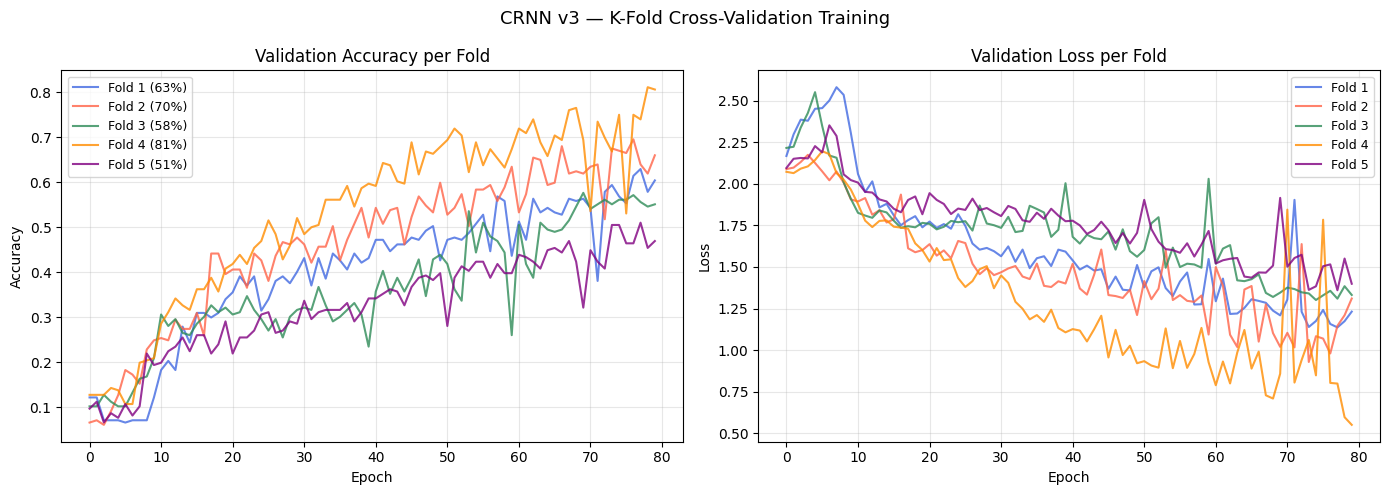

Saved → crnn_v3_kfold.png

Final held-out test evaluation...

  Test Accuracy : 86.49%
  Test Loss     : 0.3446
  Test samples  : 148

  Per-class accuracy:
    angry       :  95.2%  |███████████████████
    calm        :  90.0%  |██████████████████
    disgust     :  89.5%  |█████████████████
    fearful     : 100.0%  |████████████████████
    happy       :  58.3%  |███████████
    neutral     : 100.0%  |████████████████████
    sad         :  95.7%  |███████████████████
    surprised   : 100.0%  |████████████████████

Saved → emotion_crnn_v3_best.keras

Final test accuracy: 86.49%
Done.


In [10]:
"""
EMOTION DETECTION — CRNN v3
=============================
Problems fixed from v2:
  1. Accuracy swings (42% → 22%) caused by random splits on small data
     Fix: K-Fold cross-validation — train on all possible splits, report average
          + fixed random seeds everywhere for reproducibility

  2. Model slightly underfitting (both train and val still rising at epoch 47)
     Fix: More epochs (80), slightly wider LSTM (96 units), keep same CNN depth
          Do NOT add more CNN blocks — val was tracking train well, that's good

  3. Small dataset makes single split unreliable
     Fix: 5-fold CV gives 5 independent estimates → much more stable accuracy number

What changed vs v2:
  - CNN: same 2 blocks (16 → 32 filters) — this was working well
  - Channel compress: 32 → 8 maps (same)
  - Bridge: Permute + Reshape → (32, 256) (same)
  - LSTM: 64 → 96 units (slightly more capacity, still small)
  - Dense: 32 → 48 neurons
  - Epochs: 60 → 80
  - EarlyStopping patience: 12 → 15
  - Added: K-Fold cross-validation (5 folds)
  - Added: Fixed seeds (numpy, tensorflow, python random)
  - Added: Class weights to handle any class imbalance
"""

import os
import random
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


# ══════════════════════════════════════════════════════════
# SEED EVERYTHING — fixes the 42% → 22% swing
# With small datasets, different random splits give wildly
# different results. Fixed seeds make every run identical.
# ══════════════════════════════════════════════════════════
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ══════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════
DATA_ROOT    = "/kaggle/working/Augmented-Data"

EMOTIONS     = ["angry", "calm", "disgust", "fearful",
                "happy", "neutral", "sad", "surprised"]

TARGET_SR    = 16000
DURATION     = 10
N_MELS       = 128
N_FFT        = 2048
HOP_LENGTH   = 512
FMIN         = 0
FMAX         = 8000
TARGET_SHAPE = (128, 128)

BATCH_SIZE   = 16       # smaller batch → more gradient updates per epoch
                        # helps on small datasets (was 32)
EPOCHS       = 80       # more epochs — curves were still rising at epoch 47
LR           = 0.0005   # slightly lower LR for more stable convergence
                        # (was 0.001 — too fast for the LSTM to settle)
N_CLASSES    = len(EMOTIONS)   # 8
INPUT_SHAPE  = (128, 128, 3)
N_FOLDS      = 5        # K-Fold cross-validation


# ══════════════════════════════════════════════════════════
# PART A — AUDIO PIPELINE
# ══════════════════════════════════════════════════════════

def pad_or_trim(y, sr):
    target = DURATION * sr
    if len(y) >= target:
        return y[:target]
    return np.pad(y, (0, target - len(y)), constant_values=0)

def rms_normalize(y, target_rms=0.1):
    rms = np.sqrt(np.mean(y ** 2))
    if rms < 1e-6:
        return y
    return y * (target_rms / rms)

def pre_emphasis(y, coeff=0.97):
    return np.append(y[0], y[1:] - coeff * y[:-1])

def normalize_channel(ch):
    return (ch - ch.min()) / (ch.max() - ch.min() + 1e-6)

def resize_channel(ch):
    img = Image.fromarray((ch * 255).astype(np.uint8))
    img = img.resize((TARGET_SHAPE[1], TARGET_SHAPE[0]), Image.BILINEAR)
    return np.array(img) / 255.0

def audio_to_3channel_image(filepath):
    try:
        y, sr = librosa.load(filepath, sr=TARGET_SR, mono=True)
        y = pad_or_trim(y, sr)
        y = rms_normalize(y)
        y = pre_emphasis(y)

        S      = librosa.feature.melspectrogram(
                     y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH,
                     n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
        S_db   = librosa.power_to_db(S, ref=np.max, top_db=80)
        delta  = librosa.feature.delta(S_db)
        delta2 = librosa.feature.delta(S_db, order=2)

        ch0 = resize_channel(normalize_channel(S_db))
        ch1 = resize_channel(normalize_channel(delta))
        ch2 = resize_channel(normalize_channel(delta2))

        return np.stack([ch0, ch1, ch2], axis=-1).astype(np.float32)

    except Exception as e:
        print(f"    ✗ {Path(filepath).name}: {e}")
        return None


def build_dataset():
    all_X, all_y = [], []
    print(f"\nBuilding dataset from: {DATA_ROOT}")

    for emotion in EMOTIONS:
        folder = Path(DATA_ROOT) / emotion
        if not folder.exists():
            print(f"  SKIP — not found: {folder}")
            continue

        files = list(folder.glob("*.wav")) + list(folder.glob("*.WAV"))
        print(f"  {emotion:12s} — {len(files):4d} files ...", end="", flush=True)

        count = 0
        for f in files:
            img = audio_to_3channel_image(f)
            if img is not None:
                all_X.append(img)
                all_y.append(emotion)
                count += 1
        print(f" {count} done ✓")

    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y)

    print(f"\n  X shape : {X.shape}")
    print(f"\n  Per emotion:")
    for e in EMOTIONS:
        n = int(np.sum(y == e))
        print(f"    {e:12s}: {n:4d}  {'█' * (n // 10)}")

    os.makedirs("./features", exist_ok=True)
    np.save("./features/X_all.npy", X)
    np.save("./features/y_all.npy", y)
    print(f"\n  Saved → ./features/X_all.npy  |  ./features/y_all.npy")
    return X, y


# ══════════════════════════════════════════════════════════
# PART B — CRNN v3 MODEL
# ══════════════════════════════════════════════════════════

def build_crnn(input_shape=INPUT_SHAPE, n_classes=N_CLASSES):
    """
    CRNN v3 — same bridge as v2, slightly wider LSTM + dense.

    Shape journey:
      (128, 128, 3)
      → Conv Block 1 [16 filters]  → (64, 64, 16)
      → Conv Block 2 [32 filters]  → (32, 32, 32)
      → 1×1 compress [8 maps]      → (32, 32, 8)
      → Permute + Reshape          → (32, 256)   [32 time steps × 256 features]
      → LSTM [96 units]            → (96,)
      → Dense [48] + BN + Dropout  → (48,)
      → Output Softmax [8]         → (8,)

    Why wider LSTM (96 vs 64)?
      The v2 curves showed both train and val still rising at the end
      of training — the model hadn't fully converged yet.
      Slightly more LSTM capacity lets it learn richer temporal patterns
      without making the overall param count prohibitively large.
      96 units adds ~20k params compared to 64 — still well under 150k total.
    """

    inputs = keras.Input(shape=input_shape, name="input")

    # ── Conv Block 1: 16 filters ──────────────────────────
    x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(16, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    # Output: (64, 64, 16)

    # ── Conv Block 2: 32 filters ──────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.35)(x)
    # Output: (32, 32, 32)

    # ── 1×1 channel compression ───────────────────────────
    # Reduce 32 feature maps → 8 before the LSTM bridge
    # Each time step vector = 32 freq × 8 maps = 256 dims
    x = layers.Conv2D(8, (1, 1), padding='same', name='channel_compress')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    # Output: (32, 32, 8)

    # ── Bridge: CNN spatial map → LSTM time sequence ──────
    # Axes before: (batch, freq=32, time=32, maps=8)
    # After Permute(2,1,3): (batch, time=32, freq=32, maps=8)
    # After Reshape: (batch, time=32, 256)
    x = layers.Permute((2, 1, 3), name='permute_time_first')(x)
    x = layers.Reshape((32, 32 * 8), name='bridge_reshape')(x)
    # Output: (batch, 32, 256)

    # ── LSTM: reads the 32-step sequence ─────────────────
    # 96 units (up from 64) for slightly more temporal capacity
    # return_sequences=False → only keep the final hidden state
    # The final state = LSTM's summary of the entire emotional arc
    x = layers.LSTM(
            96,
            return_sequences = False,
            dropout          = 0.3,
            name             = 'lstm'
        )(x)
    # Output: (batch, 96)

    # ── Dense head ───────────────────────────────────────
    x = layers.Dense(48)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    # Output: (batch, 48)

    # ── Output ───────────────────────────────────────────
    outputs = layers.Dense(n_classes, activation='softmax',
                           name='output')(x)
    # Output: (batch, 8)

    return keras.Model(inputs=inputs, outputs=outputs,
                       name="EmotionCRNN_v3")


# ══════════════════════════════════════════════════════════
# PART C — K-FOLD CROSS-VALIDATION TRAINING
# Why K-Fold?
#   With ~832 total samples / 8 classes = ~104 per class
#   A single 70/15/15 split gives only ~15 val samples per class
#   One bad split (e.g. all easy "calm" samples end up in train)
#   swings accuracy by 20%+
#
#   K-Fold solution:
#   Split data into 5 equal folds. Train 5 times, each time using
#   a different fold as validation and the other 4 as training.
#   Report average accuracy across all 5 folds.
#   This is a much more reliable estimate of true model performance.
#
#   Fold 1: [val][tr][tr][tr][tr]
#   Fold 2: [tr][val][tr][tr][tr]
#   Fold 3: [tr][tr][val][tr][tr]
#   Fold 4: [tr][tr][tr][val][tr]
#   Fold 5: [tr][tr][tr][tr][val]
# ══════════════════════════════════════════════════════════

def get_callbacks(fold_num):
    """Returns fresh callbacks for each fold."""
    return [
        keras.callbacks.EarlyStopping(
            monitor              = 'val_accuracy',
            patience             = 15,
            restore_best_weights = True,
            verbose              = 0),   # silent per-epoch for cleaner output

        keras.callbacks.ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 8,
            min_lr   = 1e-6,
            verbose  = 0),

        keras.callbacks.ModelCheckpoint(
            f'best_crnn_fold{fold_num}.keras',
            monitor        = 'val_accuracy',
            save_best_only = True,
            verbose        = 0),
    ]


def train_with_kfold(X, y_int, encoder):
    """
    Trains N_FOLDS models using stratified K-Fold.
    Returns: list of histories, list of val accuracies, best model
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_val_accs  = []
    fold_histories = []
    best_model     = None
    best_val_acc   = 0.0

    print(f"\n{'='*55}")
    print(f"  {N_FOLDS}-FOLD CROSS-VALIDATION")
    print(f"  Each fold: ~{int(len(X)*0.8)} train / ~{int(len(X)*0.2)} val")
    print(f"{'='*55}\n")

    y_onehot = to_categorical(y_int, num_classes=N_CLASSES)

    # Compute class weights to handle any imbalance
    # If "calm" has 60 samples but "angry" has 120, the model
    # would learn to predict angry more often.
    # Class weights penalize mistakes on underrepresented classes more.
    class_weights_arr = compute_class_weight(
        class_weight = 'balanced',
        classes      = np.unique(y_int),
        y            = y_int
    )
    class_weight_dict = dict(enumerate(class_weights_arr))
    print(f"Class weights: { {encoder.classes_[k]: round(v, 2) for k, v in class_weight_dict.items()} }\n")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_int)):
        print(f"── Fold {fold+1}/{N_FOLDS} ──────────────────────────────")
        print(f"   Train: {len(train_idx)} samples | Val: {len(val_idx)} samples")

        X_tr, X_val   = X[train_idx], X[val_idx]
        y_tr, y_val   = y_onehot[train_idx], y_onehot[val_idx]

        # Build fresh model for each fold
        # (reusing the same model would carry over trained weights)
        tf.random.set_seed(SEED + fold)
        model = build_crnn()

        model.compile(
            optimizer = keras.optimizers.Adam(learning_rate=LR),
            loss      = 'categorical_crossentropy',
            metrics   = ['accuracy']
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data = (X_val, y_val),
            epochs          = EPOCHS,
            batch_size      = BATCH_SIZE,
            callbacks       = get_callbacks(fold + 1),
            class_weight    = class_weight_dict,
            verbose         = 1
        )

        # Get the best val accuracy this fold achieved
        best_fold_acc = max(history.history['val_accuracy'])
        fold_val_accs.append(best_fold_acc)
        fold_histories.append(history)

        print(f"   Best val accuracy fold {fold+1}: {best_fold_acc*100:.1f}%\n")

        # Track overall best model
        if best_fold_acc > best_val_acc:
            best_val_acc = best_fold_acc
            best_model   = model

    # ── Summary ───────────────────────────────────────────
    mean_acc = np.mean(fold_val_accs)
    std_acc  = np.std(fold_val_accs)

    print(f"\n{'='*55}")
    print(f"  CROSS-VALIDATION RESULTS")
    print(f"{'='*55}")
    for i, acc in enumerate(fold_val_accs):
        print(f"  Fold {i+1}: {acc*100:.1f}%")
    print(f"{'─'*55}")
    print(f"  Mean accuracy : {mean_acc*100:.1f}% ± {std_acc*100:.1f}%")
    print(f"  Best fold     : {max(fold_val_accs)*100:.1f}%")
    print(f"{'='*55}\n")

    return fold_histories, fold_val_accs, best_model


def plot_kfold_histories(histories, fold_accs):
    """Plots accuracy curves for all folds on one chart."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("CRNN v3 — K-Fold Cross-Validation Training", fontsize=13)

    colors = ['royalblue', 'tomato', 'seagreen', 'darkorange', 'purple']

    for i, history in enumerate(histories):
        axes[0].plot(history.history['val_accuracy'],
                     color=colors[i], alpha=0.8,
                     label=f'Fold {i+1} ({fold_accs[i]*100:.0f}%)')
        axes[1].plot(history.history['val_loss'],
                     color=colors[i], alpha=0.8,
                     label=f'Fold {i+1}')

    axes[0].set_title("Validation Accuracy per Fold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Validation Loss per Fold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    # Add mean line on accuracy plot
    max_epochs = max(len(h.history['val_accuracy']) for h in histories)
    for i, history in enumerate(histories):
        pad = [None] * (max_epochs - len(history.history['val_accuracy']))
        _ = history.history['val_accuracy'] + pad

    plt.tight_layout()
    plt.savefig("crnn_v3_kfold.png", dpi=100)
    plt.show()
    plt.close()
    print("Saved → crnn_v3_kfold.png")


def final_test_evaluation(best_model, X, y_int, encoder):
    """
    After K-Fold, do one final held-out test on 15% of data.
    This is the honest final number to report.
    """
    print("\nFinal held-out test evaluation...")

    # Hold out 15% as a true test set (stratified, fixed seed)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y_int,
        test_size    = 0.15,
        stratify     = y_int,
        random_state = SEED
    )

    y_test_onehot = to_categorical(y_test, num_classes=N_CLASSES)
    test_loss, test_acc = best_model.evaluate(X_test, y_test_onehot, verbose=0)

    print(f"\n  Test Accuracy : {test_acc*100:.2f}%")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test samples  : {len(X_test)}")

    # Per-class accuracy
    y_pred = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
    print(f"\n  Per-class accuracy:")
    for i, cls in enumerate(encoder.classes_):
        mask    = y_test == i
        if mask.sum() == 0:
            continue
        cls_acc = np.mean(y_pred[mask] == i)
        bar     = "█" * int(cls_acc * 20)
        print(f"    {cls:12s}: {cls_acc*100:5.1f}%  |{bar}")

    return test_acc


def predict_file(model, encoder, filepath):
    img = audio_to_3channel_image(filepath)
    if img is None:
        print("Could not process file.")
        return
    probs        = model.predict(img[np.newaxis], verbose=0)[0]
    pred_idx     = np.argmax(probs)
    pred_emotion = encoder.classes_[pred_idx]
    print(f"\nPrediction: {pred_emotion}  ({probs[pred_idx]*100:.1f}%)")
    for cls, p in zip(encoder.classes_, probs):
        bar = "█" * int(p * 40)
        tag = " ←" if cls == pred_emotion else ""
        print(f"  {cls:12s} {p:.3f}  |{bar}{tag}")


# ══════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ── Stage 1: Build dataset (comment out after first run) ──
    # X, y_str = build_dataset()

    # ── Stage 2: Load saved features ─────────────────────────
    X     = np.load("./features/X_all.npy")
    y_str = np.load("./features/y_all.npy")
    print(f"Loaded: X={X.shape}  y={y_str.shape}")

    # ── Stage 3: Encode labels to integers ───────────────────
    encoder = LabelEncoder()
    y_int   = encoder.fit_transform(y_str)   # strings → 0-7

    print("\nLabel encoding:")
    for i, cls in enumerate(encoder.classes_):
        print(f"  {cls:12s} → {i}")

    # ── Stage 4: K-Fold training ──────────────────────────────
    histories, fold_accs, best_model = train_with_kfold(X, y_int, encoder)

    # ── Stage 5: Plot all fold curves ────────────────────────
    plot_kfold_histories(histories, fold_accs)

    # ── Stage 6: Final held-out test ─────────────────────────
    test_acc = final_test_evaluation(best_model, X, y_int, encoder)

    # ── Stage 7: Save best model ──────────────────────────────
    best_model.save("emotion_crnn_v3_best.keras")
    print("\nSaved → emotion_crnn_v3_best.keras")
    print(f"\nFinal test accuracy: {test_acc*100:.2f}%")
    print("Done.")